## Step 1 - Understand Business Requirements & Nature of Data

## Step 2 - Classify the problem as supervised/unsupervised & regression/classification

## Step 3 - Download, clean & explore the data and create new features

In [111]:
import os
import opendatasets as od
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [5]:
od.download('https://www.kaggle.com/datasets/vipullrathod/fish-market')

Dataset URL: https://www.kaggle.com/datasets/vipullrathod/fish-market


100%|███████████████████████████████████████████████████████████████████████████████████████████| 2.38k/2.38k [00:00<00:00, 304kB/s]

In [4]:
fish = pd.read_csv('./fish-market/Fish.csv')

In [5]:
fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


### Data Cleaning

In [6]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


Aucune entrée nulle.

In [7]:
fish.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [8]:
fish[fish['Weight'] == 0]

,Species,Weight,Length1,Length2,Length3,Height,Width
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516


Retirons la valeur absurde de poids nul.

In [9]:
fish = fish[fish['Weight'] != 0]

In [10]:
fish.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis and Visualization

- Study the distributions of individual columns (uniform, normal, exponential)
- Detect anomalies or errors in the data (e.g. missing/incorrect values)
- Study the relationship of target column with other columns (linear, non-linear etc.)
- Gather insights about the problem and the dataset
- Come up with ideas for preprocessing and feature engineering

In [11]:
fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


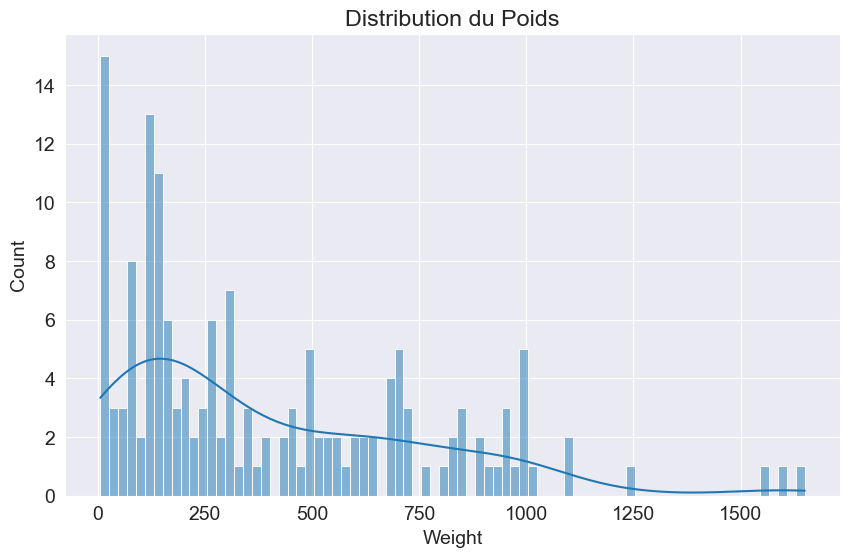

In [12]:
plt.title("Distribution du Poids")
sns.histplot(data=fish, x='Weight', kde=True, bins=fish.shape[0]//2)
plt.show()

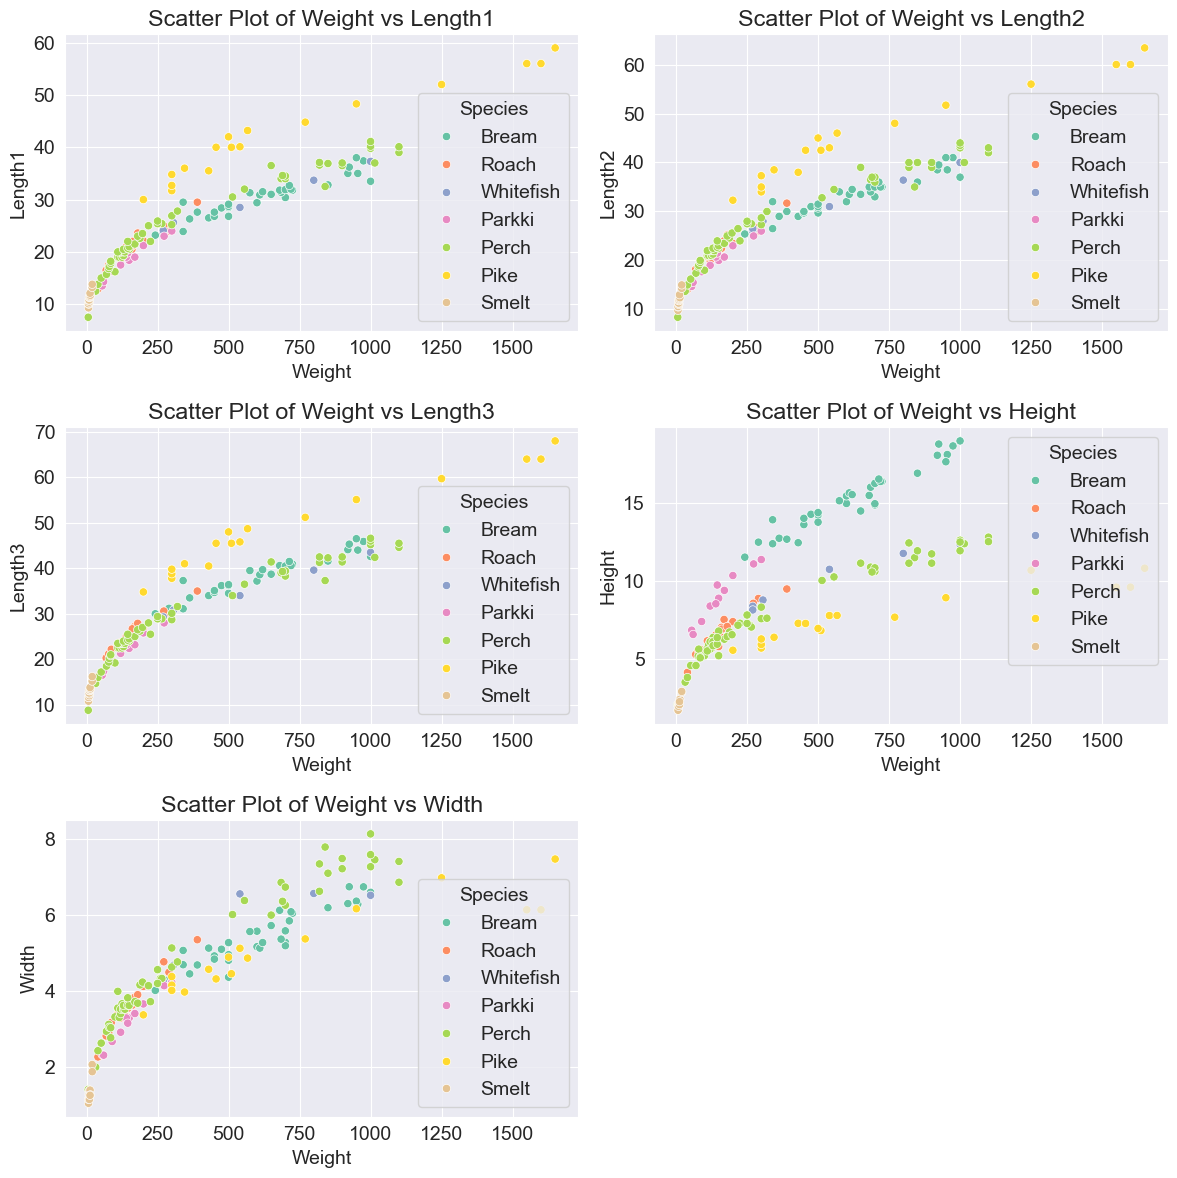

In [13]:
columns_to_analyze = ['Length1', 'Length2', 'Length3', 'Height', 'Width']

# Create scatter plots with 'Weight', other columns, and color-coded by 'Species'
plt.figure(figsize=(12, 12))
for i, column in enumerate(columns_to_analyze, 1):
    plt.subplot(3, 2, i)
    sns.scatterplot(data=fish, x='Weight', y=column, hue='Species', palette='Set2')
    plt.title(f'Scatter Plot of Weight vs {column}')
    plt.xlabel('Weight')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

Une tendance non linéaire se dégage.

In [14]:
fish.iloc[:, 1:].corr()['Weight'].sort_values(ascending=False)

Weight     1.000000
Length3    0.923090
Length2    0.918603
Length1    0.915719
Width      0.886654
Height     0.723857
Name: Weight, dtype: float64

Toutes les données ont une grosse corrélations et donc sont pertinentes.

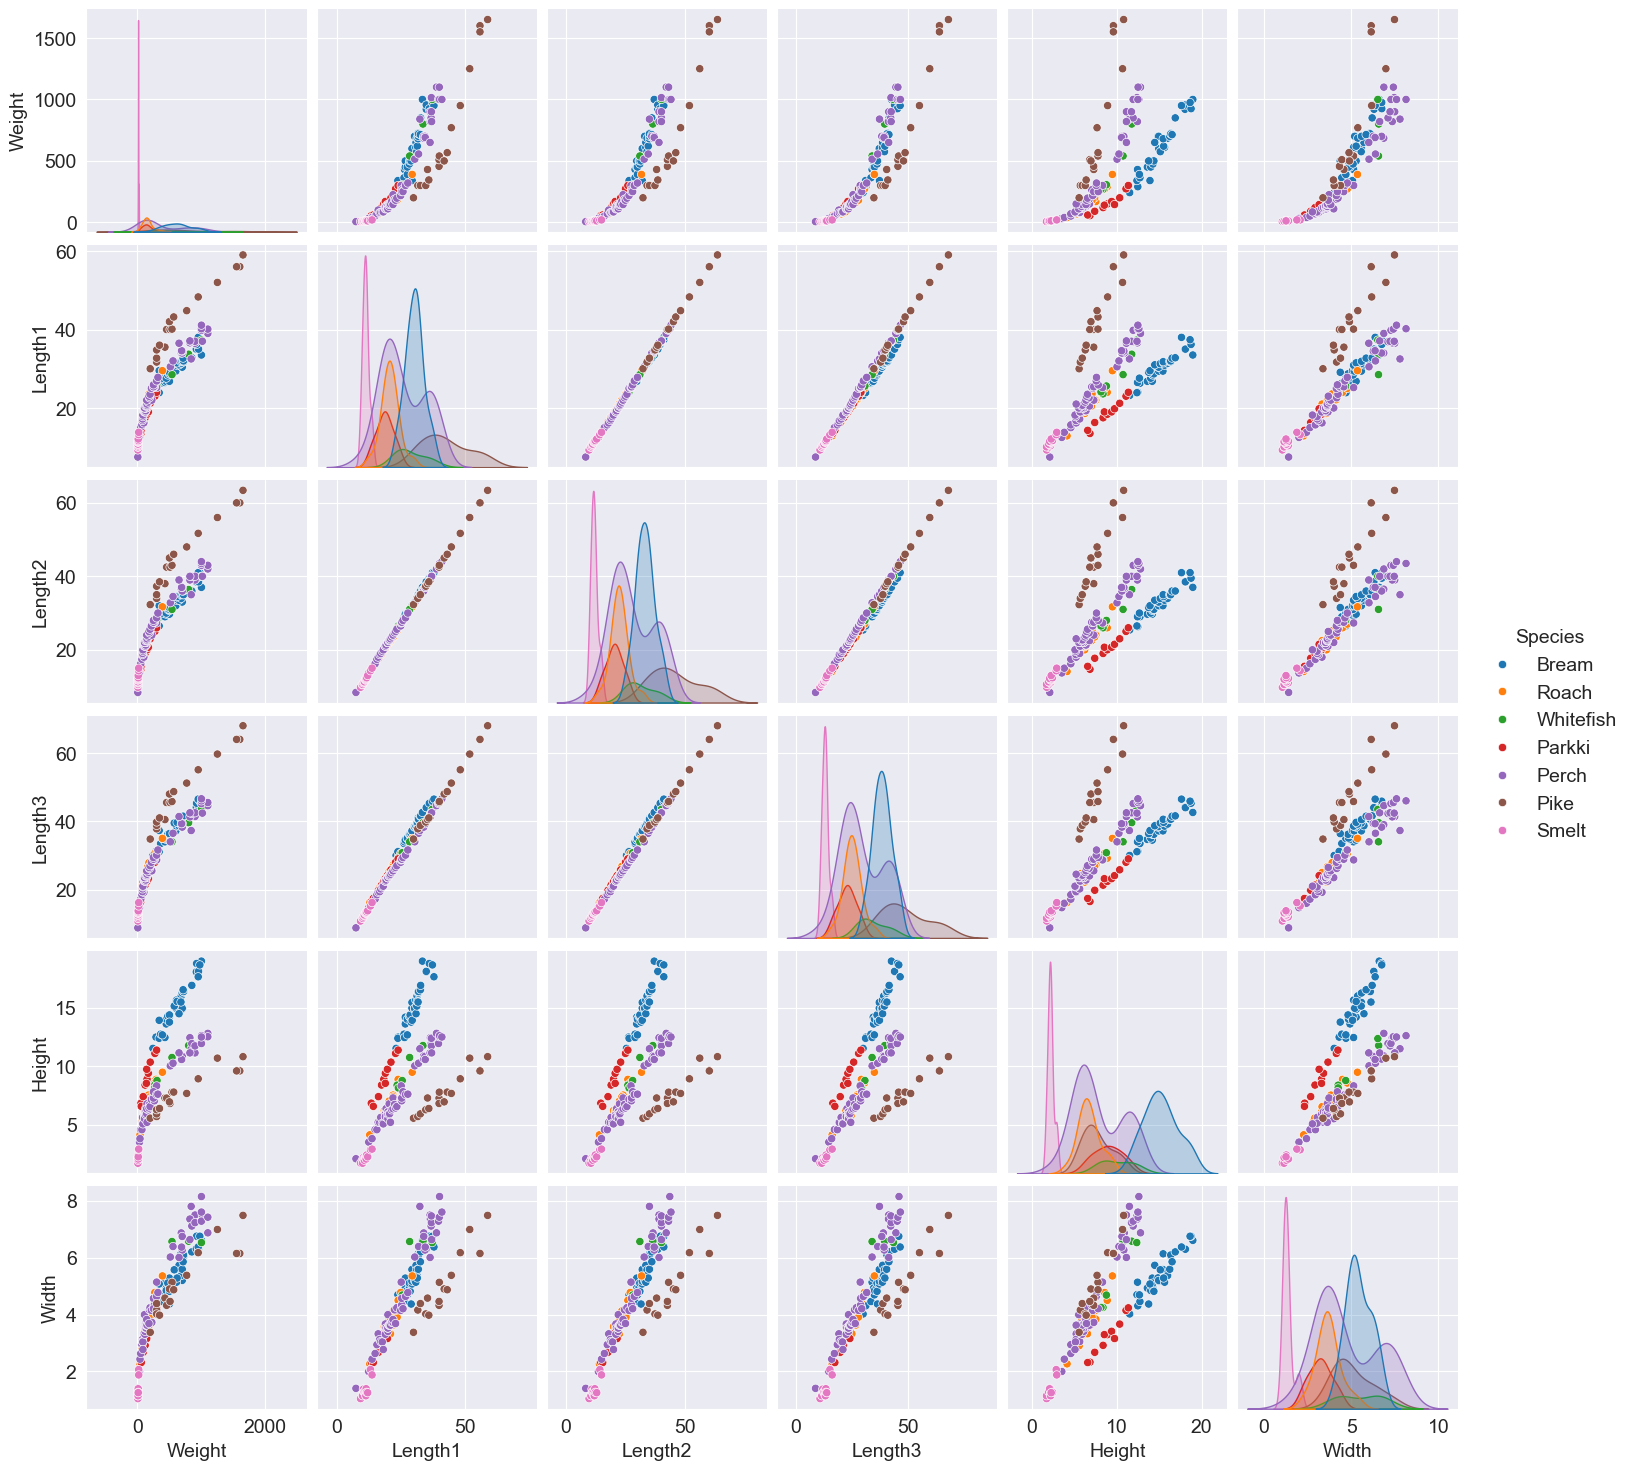

In [121]:
sns.pairplot(data=fish, hue='Species')

Je ne ferais pas de feature engineering car les données sont relativement simples et déjà assez pertinentes pour entraîner un simple modèle.

## Step 4 - Create a training/test/validation split and prepare the data for training

Une bonne pratique est de séparer son dataset en plusieurs morceaux afin de pouvoir le tester après l'entraînement. Avec de gros dataset on peut même le découper en 3 parties, train validation et test set. Comme mon dataset ne comprend que 159 exemples, je me contenterais de le séparer en train set (80%) et test set (20%) uniquement.

In [15]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(fish, test_size=0.2, random_state=42)

In [16]:
print(train_df.shape)
print(test_df.shape)

(126, 7)
(32, 7)


On sépare les colonnes inputs de la colonne target

In [17]:
input_cols = train_df.columns.drop('Weight')
target_col = 'Weight'

In [18]:
print("input_cols : ", input_cols)
print("target_col : ", target_col)

input_cols :  Index(['Species', 'Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')
target_col :  Weight


On va égalemment séparer les colonnes numérique des colonnes catégorielles avant des les traiter individuellement.

In [19]:
numeric_cols = list(fish[input_cols].select_dtypes(include=['float64']).columns)
categorical_cols = fish[input_cols].select_dtypes('object').columns.tolist()

In [20]:
print("numeric_cols : ", numeric_cols)
print("categorical_cols : ", categorical_cols)

numeric_cols :  ['Length1', 'Length2', 'Length3', 'Height', 'Width']
categorical_cols :  ['Species']


On créer enfin les dataframe contenant les `inputs_cols` et la `target_col`

In [21]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

### Imputation, Scaling et Encoding
Une autre étape importante est la gestion des valeurs manquantes, la normalisation des données et la conversion des données textuelles en données numériques. Notre dataset ne contient aucune valeur manquante, donc passons au reste.

### Scaling
Normaliser les données permet à notre modèle d'obtenir de meilleurs résultats car on réduit la variance des données. Plusieurs méthodes existe, une des plus connus est le `MinMaxScaler` qui prend la valeur minimum et maximum pour chaque caractéristique et compresse les donnes dans l'intervalle [0, 1].

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler().fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [23]:
train_inputs.describe()

,Length1,Length2,Length3,Height,Width
count,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.360826,0.360534,0.374745,0.417031,0.497167
std,0.193267,0.193644,0.194239,0.240716,0.248839
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.223786,0.229091,0.237753,0.249985,0.345731
50%,0.341748,0.340909,0.347128,0.347274,0.474274
75%,0.489320,0.497273,0.519848,0.596398,0.641218
max,1.000000,1.000000,1.000000,1.000000,1.000000


On encode les colonnes numériques à l'aide de la méthode `One-Hot Encoding` qui transforme toutes les étiquettes uniques en colonne binaire, voici un exemple imagé :

![](https://i.imgur.com/n8GuiOO.png)

De cette façon, on tranforme les étiquettes en données numériques qui sont utiles pour trouver de potentielles corrélation dans notre modèle.

In [24]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [25]:
print(encoded_cols)

['Species_Bream', 'Species_Parkki', 'Species_Perch', 'Species_Pike', 'Species_Roach', 'Species_Smelt', 'Species_Whitefish']


Voici à quoi ressemble notre dataframe après Scaling et Encoding

In [26]:
train_inputs.head()

,Species,Length1,Length2,Length3,Height,Width,Species_Bream,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish
138,Pike,0.693204,0.683636,0.673986,0.355748,0.566441,0.0,0.0,0.0,1.0,0.0,0.0,0.0
56,Whitefish,0.322330,0.329091,0.346284,0.376518,0.474341,0.0,0.0,0.0,0.0,0.0,0.0,1.0
127,Perch,0.652427,0.647273,0.638514,0.631781,0.970377,0.0,0.0,1.0,0.0,0.0,0.0,0.0
85,Perch,0.229126,0.234545,0.236486,0.273000,0.368459,0.0,0.0,1.0,0.0,0.0,0.0,0.0
155,Smelt,0.081553,0.072727,0.079392,0.040622,0.032809,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Et voici la version finale prétraitée des dataframe en train/test et inputs/target.

In [27]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]
y_train = train_targets
y_test = test_targets

## Step 5 - Create quick & easy baseline models to benchmark future models

Nous allons créer des modèles de bases qui vont nous permettre de savoir quel score notre modèle doit obtenir au minimum pour être plus efficace qu'un modèle aléatoire ou simple.

### Random/Fixed guess

In [28]:
def guess_random(inputs):
    lo, hi = fish.Weight.min(), fish.Weight.max()
    return np.random.random(len(inputs)) * (hi - lo) + lo

Evaluons la performance de ce modèle sur `X_train` avec la fonction de coût RMSE.

In [29]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(guess_random(X_train), y_train)

703.5766203036576

Interpretation :
En moyenne le modèle se trompe de 703 grammes.

In [30]:
def return_mean(inputs):
    return np.full(len(inputs), fish.Weight.mean())

In [31]:
root_mean_squared_error(return_mean(X_train), train_targets)

353.2604162777652

Interpretation: En moyenne le modèle se trompe de 353 grammes.

### Baseline Model
Nous allons entraîner un modèle de régression linéaire grâce au module inclus dans sklearn. Il existe plusieurs façon de faire une régression, la méthode la plus connu est sans doute la descente de gradient qui permet de faire converger la fonction de coût vers un minimum local, mais quand notre dataset est petit (environ moins de 10 000 exemples), on se tourne vers la méthode de l'équation normale qui calcule directement le minimum grâce à l'équation :
$$\theta = (X^{T}X)^{-1} X^{T} y$$

Cette notation correspond à la représentation matricielle des données où $\theta$ correspond au vecteur correspondant au paramètre (ceux qui sont modifiés pour trouvé l'erreur minimale), $X$ est la matrice contenant les caractéristiques (`fish[input_cols]`) et $y$ le vecteur target (`target_cols`)

In [32]:
from sklearn.linear_model import LinearRegression 

model = LinearRegression()
model.fit(X_train, train_targets)
root_mean_squared_error(model.predict(X_train), train_targets)

94.08144049127576

Notre modèle de régression linéaire a déjà une meilleure performance que nos modèles précédents avec seulement une rmse de 94 grammes. Mais il se pourrait qu'il fasse de l'overfitting. Nous allons essayer différents modèles à l'aide d'une fonction qui s'entraîne et calcul la rmse, mais incorporons une cross validation pour éviter l'overfitting et avoir des résultat plus fiables. La cross validation, en dépit de ne pas avoir de validation set, nous permet d'entraîner un modèle plusieurs fois et à chaque fois, une partie différente de `X_train` sert de validation. Ainsi, on obtient une estimation robuste du sur-apprentissage (overfitting).

In [63]:
from sklearn.model_selection import cross_val_score

# Voici un exemple de fonction sans cross validation, vulnérable à l'overfitting
def try_model_vulnerable(model):
    # Fit the model
    model.fit(X_train, train_targets)
    
    # Generate predictions
    train_preds = model.predict(X_train)
    
    # Compute RMSE
    train_rmse = root_mean_squared_error(y_train, train_preds)
    return train_rmse

# Fonction avec cross validation, plus robuste
def try_model(model):
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    
    rmse_cv = -scores.mean()
    return rmse_cv

J'ai déjà parlé de LinearRegression et SGDRegressor (descente de gradient). D'autres méthode dites de regularization existent tels que Ridge, Lasso, ElasticNet pour éviter l'overfitting, c'est à dire quand on surentraîne un modèle jusqu'à ce qu'il retienne par coeur les données d'entrée mais qui généralise mal sur de nouvelles données.

In [34]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

In [64]:
try_model(LinearRegression())

np.float64(107.18246415685526)

In [65]:
try_model(SGDRegressor(max_iter=10_000))

np.float64(109.20272120443465)

In [66]:
try_model(Ridge())

np.float64(112.29176128967296)

In [67]:
try_model(Lasso())

C:\Users\Eric\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.551e+03, tolerance: 1.190e+03
  model = cd_fast.enet_coordinate_descent(


np.float64(108.82918325903252)

In [68]:
try_model(ElasticNet())

np.float64(260.77006407894555)

On peut s'amuser à changer les hyperparamètres des modèles pour les améliorer, mais je vais garder les performances telles quelles et me pencher sur une autre famille de régression que les régression linéaires : les arbres.

In [69]:
from sklearn.tree import DecisionTreeRegressor #, plot_tree

tree = DecisionTreeRegressor(random_state=42)
try_model(tree)

np.float64(106.81240263365999)

Cette valeur est plus proche que celles que nous avaons trouvé avec les autres modèles. Voyons si réduire la profondeur maximum diminue la rmse.

In [70]:
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
try_tree(tree)

np.float64(102.44495369786878)

Bien que l'ajustement des hyperparamètres d'un seul arbre de décision puisse apporter certaines améliorations, une stratégie beaucoup plus efficace consiste à combiner les résultats de plusieurs arbres de décision entraînés avec des paramètres légèrement différents. C'est ce qu'on appelle une Random Forest.

L'idée principale ici est que chaque arbre de décision de la forêt commettra différents types d'erreurs et qu'en faisant la moyenne, bon nombre de ces erreurs s'annuleront. Cette idée est également connue sous le nom de "Wisdom of the crowd" (sagesse de la foule). Une forêt aléatoire fonctionne en calculant la moyenne/en combinant les résultats de plusieurs arbres de décision :

<img src="https://1.bp.blogspot.com/-Ax59WK4DE8w/YK6o9bt_9jI/AAAAAAAAEQA/9KbBf9cdL6kOFkJnU39aUn4m8ydThPenwCLcBGAsYHQ/s0/Random%2BForest%2B03.gif" width="640">

In [47]:
from sklearn.ensemble import RandomForestRegressor

In [71]:
%%time
rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
try_model(rf)

CPU times: total: 4.09 s
Wall time: 5.85 s


np.float64(63.08866536517007)

On voit une baisse significative de la fonction d'erreur grâce à la Random Forest. Essayons une régression polynomiale pour saisir une relation non linéaire. On ne doit pas appliquer `PolynomialFeatures` avant la cross-validation car on risque un data leakage, c'est à dire que les statistiques de transformation “voient” tout le dataset. Pour combiner cross-validation et régression polynomiale, on utilise une `Pipeline` un peu comme un chef d'orchestre.

In [55]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [56]:
model = LinearRegression()
model.fit(X_train_poly, train_targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
y_pred = model.predict(X_test_poly)

In [58]:
root_mean_squared_error(model.predict(X_test_poly), y_test)

69.04544026892957

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linreg", LinearRegression())
])

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_cv = -scores.mean()
rmse_cv

np.float64(96.28926821982381)

On peut tester différents degrés mais la fonction correspondant au mieux aux exemple dans nos visualisations s'apparentait plus à du degré 2.

In [74]:
for d in [1, 2, 3, 4]:
    pipeline = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("linreg", LinearRegression())
    ])
    
    scores = cross_val_score(
        pipeline,
        X_train,
        train_targets,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    
    print(f"Degree {d} | RMSE CV: {-scores.mean():.2f}")


Degree 1 | RMSE CV: 107.18
Degree 2 | RMSE CV: 96.29
Degree 3 | RMSE CV: 4190.09
Degree 4 | RMSE CV: 2133.57


En conlusion : La Random Forest reste au dessus.

## Step 7 - Interpret models, study individual predictions & present your findings
### Feature Importance.

In [91]:
rf.fit(X_train, y_train)

rf.feature_importances_

array([5.07291172e-02, 7.08108741e-02, 1.36538887e-01, 1.02186428e-02,
       7.22646774e-01, 2.88675766e-04, 3.95950639e-05, 2.17374129e-04,
       7.76066880e-03, 2.83999102e-04, 2.19879886e-05, 4.43404503e-04])

In [92]:
importance_df = pd.DataFrame({ 
    'feature': numeric_cols+encoded_cols, 
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

C:\Users\Eric\AppData\Local\Temp\ipykernel_8644\1606860202.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(6), x='importance', y='feature', palette='Set2');


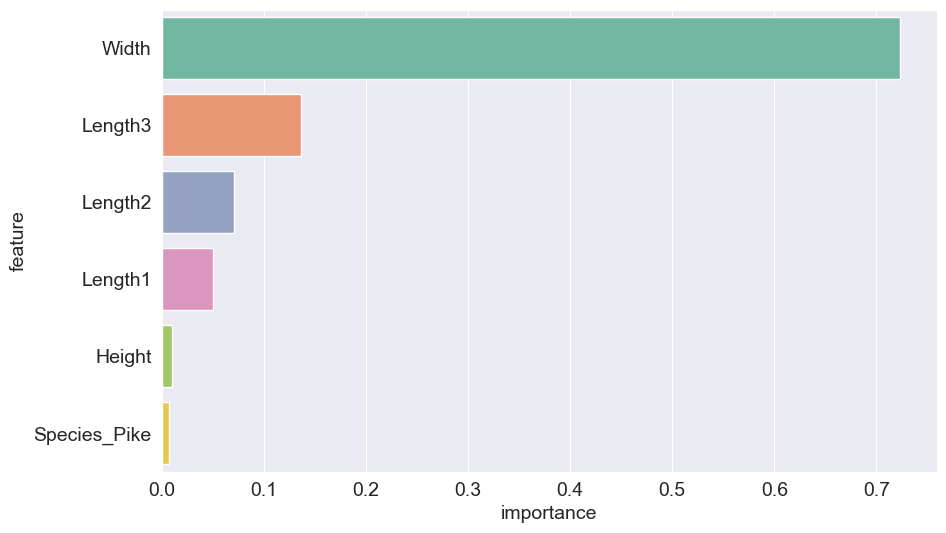

In [100]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(6), x='importance', y='feature', palette='Set2');

Le graphique ci-dessus peut être présenté aux parties prenantes non formés au ML afin d'expliquer comment le modèle parvient à son résultat.

### Looking at individual predictions

In [101]:
def predict_input(model, single_input):
    input_df = pd.DataFrame([single_input])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    pred = model.predict(X_input)[0]
    return pred

In [102]:
fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [105]:
sample_input = {'Species': 'Bream',
 'Length1': 23.5,
 'Length2': 25.6,
 'Length3': 30.3,
 'Height': 11.6,
 'Width': 4.1
}

sample_input

{'Species': 'Bream',
 'Length1': 23.5,
 'Length2': 25.6,
 'Length3': 30.3,
 'Height': 11.6,
 'Width': 4.1}

In [106]:
predict_input(rf, sample_input)

np.float64(253.08)

En regardant notre 1er exemple dans notre dataset, on trouve une résultat assez similaire.

In [108]:
fish.iloc[0]

Species    Bream
Weight     242.0
Length1     23.2
Length2     25.4
Length3     30.0
Height     11.52
Width       4.02
Name: 0, dtype: object

Merci d'avoir pris le temps de regarder mon projet.